In [1]:
import math
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
manual_annotation=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\manual_annotation.csv",header=None)
head_curvature=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\head_curvature.csv",header=None)
df_speed=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\rev_speed.csv",header=None)
df_angular_speed=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\angular_speed.csv",header=None)
df_head_freq=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\head_oscillation_frequency.csv",header=None)
df_curvature=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\total_curvature.csv",header=None)
df_rev_run=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\time_from_rev.csv",header=None)
df_roam_dwell=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\roaming_dwelling_vector.csv",header=None)

In [101]:
df_speed

,0,1,2,3,4,5,6,7,8,9,...,18890,18891,18892,18893,18894,18895,18896,18897,18898,18899
0,0.147140,0.14714,0.130000,0.131610,0.123940,0.131610,0.130000,0.135330,0.103790,0.105950,...,0.097268,0.086023,0.102590,0.060083,0.084172,0.102770,0.111680,0.140290,0.113160,NaN
1,0.142640,0.12394,0.102320,0.124920,0.112640,0.106630,0.104690,0.124890,0.098387,0.131610,...,0.133540,0.107230,0.151000,0.158000,0.158110,0.132000,0.123940,0.102770,0.083024,NaN
2,0.022472,0.01300,0.000000,0.000000,0.009220,0.006000,0.007000,0.013416,0.018385,0.013416,...,0.163710,0.194260,0.181340,0.142870,0.148060,0.181300,0.206020,0.144700,0.087664,NaN
3,0.164280,0.17899,0.170100,0.126560,0.127460,0.109930,0.125030,0.134650,0.082680,0.104850,...,0.006000,0.014318,0.006000,0.014318,0.008485,0.014318,0.012000,0.014765,0.013416,NaN
4,0.245730,0.20512,0.156850,0.138660,0.145340,0.081835,0.076059,0.109040,0.103410,0.136180,...,-0.054424,-0.071568,-0.095000,-0.201090,-0.202090,-0.227320,-0.221380,-0.202420,-0.245000,NaN
5,0.225850,0.22145,0.256820,0.208120,0.141150,0.228670,0.209390,0.188740,0.200000,0.215080,...,0.151530,0.102320,0.146260,0.107910,0.129760,0.138320,0.103790,0.082680,0.099865,NaN
6,0.187240,0.16980,0.144100,0.136570,0.085071,0.105650,0.148060,0.102320,0.055902,0.091482,...,0.227110,0.189860,0.197720,0.174200,0.125570,0.175330,0.183470,0.135820,0.151530,NaN
7,NaN,NaN,NaN,NaN,NaN,0.076000,0.095901,0.111400,0.094578,0.070214,...,0.106780,0.121040,0.148390,0.156200,0.129450,0.107810,0.111130,0.131240,0.107170,NaN
8,0.284480,0.26833,NaN,0.270180,0.231950,0.253570,0.217190,0.203710,0.213460,0.223580,...,0.119220,0.133460,0.132560,0.148280,0.147140,0.177020,0.170140,0.139130,0.082219,NaN
9,0.177770,0.17114,0.158980,0.148490,0.171450,0.200530,0.194740,0.184360,0.211600,0.185880,...,0.089202,0.100840,0.102770,0.076942,0.088955,0.107000,0.076236,0.107230,0.095000,NaN


In [54]:
fps=10
    
# def classify_run(start_index, fps=10):
#     # Categorize based on the start index
#     if start_index <= 457 * fps:
#         return 'spontaneous'
    
#     for base in range(4570, 18071, 90 * fps):
#         if base <= start_index <= base + 8.5 * fps:
#             return 'sensory-evoked'
    
#     return 'spontaneous'
    
def classify_run(start_index, fps=10):
    # Categorize based on the start index
    if start_index <= 457 * fps:
        return 'spontaneous'
    
    for base in range(4570, 18071, 90 * fps):
        if base <= start_index <= base + 8.5 * fps:
            return 'sensory-evoked'
    
    return 'rest'
    
def label_dorsal_ventral(value):
    # Label based on the sign of the value
    if pd.isna(value):
        return np.nan
    elif value < 0:
        return 'dorsal'

    elif value > 0:
        return 'ventral'
    else:
        return np.nan
        
def find_peak_before_switch(values):
    # Initialize variables for tracking the max absolute value before a sign switch
    max_value = 0
    max_idx = -1
    initial_sign = np.sign(values[0])
    
    # Loop through the values to find the peak before a sign switch
    for i, value in enumerate(values):
        current_sign = np.sign(value)

        if current_sign != initial_sign:  # Check for sign switch
            break
        if abs(value) > abs(max_value):  # Track the max absolute value
            max_value = value
            max_idx = i
    return max_value, max_idx    

def find_runlengths_and_classify(df, dor_vent_df, df_speed, fps=10):
    final_results = []
    
    for col in df.columns:
        run_lengths = []
        start_indices = []
        end_indices = []
        
        data = df[col].values
        n = len(data)
        
        run_length = 0
        start_index = None
        
        for i in range(n):
            if data[i] == 1:
                if run_length == 0:
                    start_index = i  # Start of a new run
                run_length += 1
            else:
                if run_length > 0:
                    # Store completed run details
                    run_lengths.append(run_length)
                    start_indices.append(start_index)
                    end_indices.append(start_index + run_length - 1)
                    run_length = 0  # Reset run length
        
        # If the column ends with a run, save the last run details
        if run_length > 0:
            run_lengths.append(run_length)
            start_indices.append(start_index)
            end_indices.append(start_index + run_length - 1)
        
        for start, length, end in zip(start_indices, run_lengths, end_indices):
            # Classify the run based on the start index
            category = classify_run(start, fps)
            
            # Extract values after the end of the run up to the next sign switch
            if end + 1 < len(dor_vent_df):
                segment_values = dor_vent_df.iloc[end + 1:, dor_vent_df.columns.get_loc(col)].values
                peak_value, peak_idx = find_peak_before_switch(segment_values)
                label = label_dorsal_ventral(peak_value)
            else:
                peak_value = np.nan
                label = np.nan
            
            # Calculate the mean speed during the run (ignoring NaN values)
            speed_values = df_speed.iloc[start:end + 1, df_speed.columns.get_loc(col)].values
            mean_speed = np.nanmean(speed_values) if not np.all(np.isnan(speed_values)) else np.nan
            
            # Store the result for each run
            final_results.append({
                'worm': col, 
                'start_index': start, 
                'end_index': end,
                'run_length': length / fps,  # Convert to seconds
                'category': category,
                'peak_value': peak_value,  # Local peak before a sign switch
                'peak_label': label,
                'mean_speed': mean_speed   # Average speed during the run
            })
    
    # Convert results to a DataFrame
    final_df = pd.DataFrame(final_results)
    return final_df

In [131]:
# def plot_runlengths_by_category(df):
#     # Create the plot
#     plt.figure(figsize=(10, 6))
#     sns.boxplot(x='category', y='run_length', data=df, palette='Set2')
    
#     # Add title and labels
#     plt.title('Run Lengths by Category', fontsize=16)
#     plt.xlabel('Category', fontsize=12)
#     plt.ylabel('Rev Length (s)', fontsize=12)
    
#     # Display the plot
#     plt.show()

def plot_runlengths_by_category(df,category):
    plt.figure(figsize=(6, 6))
    
    # Create the violin plot for run lengths
    sns.violinplot(x='category', y=category, data=df, palette='Set2', inner=None)
    
    # Overlay individual points using stripplot
    sns.stripplot(x='category', y=category, data=df, color='k', size=5, jitter=True, alpha=0.7)
    
    # Add title and labels
    plt.title('Reversal speed', fontsize=16)
    plt.xlabel('Reversals', fontsize=12)
    plt.ylabel('Reversal speed (mm/s)', fontsize=12)
    # plt.ylim(-0.3,0.02)
    plt.tight_layout()
    # Adjust layout   
    plt.rcParams['svg.fonttype'] = 'none'
# Save the figure
    # plt.savefig('Rev_speed.svg', format='svg', dpi=300)
    # Display the plot
    plt.show()

In [118]:
rev_length=find_runlengths_and_classify(manual_annotation,head_curvature,df_speed.T)
rev_length

,worm,start_index,end_index,run_length,category,peak_value,peak_label,mean_speed
0,0,972,983,1.2,spontaneous,-0.014052,dorsal,-0.091293
1,0,1003,1044,4.2,spontaneous,-0.045185,dorsal,-0.186930
2,0,1279,1327,4.9,spontaneous,-0.089651,dorsal,-0.142051
3,0,1444,1483,4.0,spontaneous,0.074574,ventral,-0.121197
4,0,1736,1786,5.1,spontaneous,-0.053934,dorsal,-0.158046
...,...,...,...,...,...,...,...,...
1054,24,15956,15992,3.7,rest,0.151696,ventral,-0.211565
1055,24,16864,16879,1.6,rest,0.153702,ventral,-0.150363
1056,24,17817,17851,3.5,rest,0.162838,ventral,-0.204745
1057,24,18084,18120,3.7,sensory-evoked,0.124525,ventral,-0.205501


In [126]:
rev_length_filtered=rev_length[rev_length['category'].isin(['spontaneous', 'sensory-evoked'])]
rev_length_filtered

,worm,start_index,end_index,run_length,category,peak_value,peak_label,mean_speed,abs_peak_value
0,0,972,983,1.2,spontaneous,-0.014052,dorsal,-0.091293,0.014052
1,0,1003,1044,4.2,spontaneous,-0.045185,dorsal,-0.186930,0.045185
2,0,1279,1327,4.9,spontaneous,-0.089651,dorsal,-0.142051,0.089651
3,0,1444,1483,4.0,spontaneous,0.074574,ventral,-0.121197,0.074574
4,0,1736,1786,5.1,spontaneous,-0.053934,dorsal,-0.158046,0.053934
...,...,...,...,...,...,...,...,...,...
1045,24,7334,7344,1.1,sensory-evoked,-0.106074,dorsal,-0.130783,0.106074
1049,24,13650,13715,6.6,sensory-evoked,0.148147,ventral,-0.170230,0.148147
1051,24,14534,14596,6.3,sensory-evoked,0.108287,ventral,-0.146562,0.108287
1053,24,15424,15444,2.1,sensory-evoked,0.034741,ventral,-0.189613,0.034741


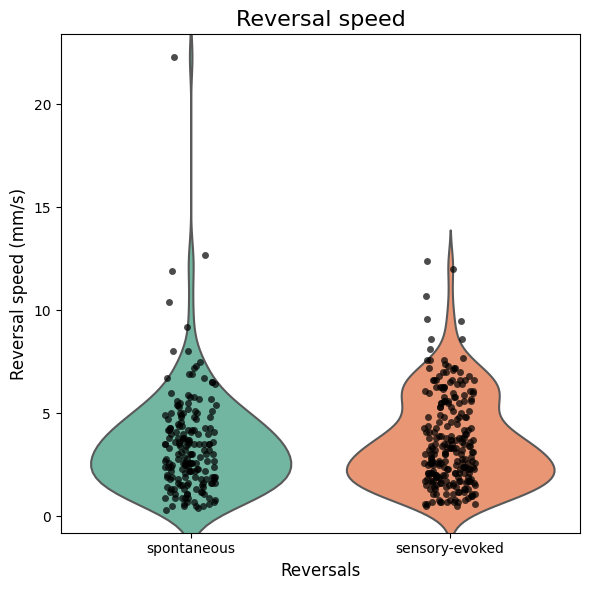

In [132]:
plot_runlengths_by_category(rev_length_filtered, category='run_length')

In [119]:
def count_runlengths_by_category(df):
    # Group by the 'category' column and count the occurrences
    category_counts = df.groupby('category').size().reset_index(name='count')
    return category_counts

# Get the counts for each category
category_counts = count_runlengths_by_category(rev_length)

# Print the counts
print(category_counts)


         category  count
0            rest    631
1  sensory-evoked    243
2     spontaneous    185


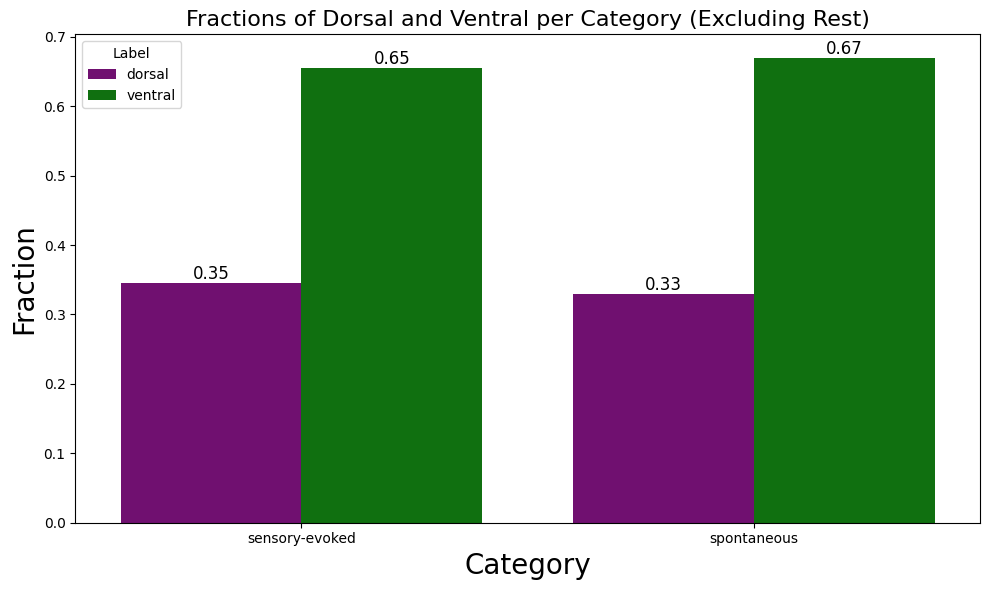

In [107]:

def plot_dorsal_ventral_fractions(df):
    # Exclude the 'rest' category
    df_filtered = df[df['category'].isin(['spontaneous', 'sensory-evoked','rest'])]
    
    # Group by category and peak_label to get counts for each category-label combination
    count_df = df_filtered.groupby(['category', 'peak_label']).size().unstack(fill_value=0)
    
    # Re-index to ensure 'dorsal' and 'ventral' columns exist, filling missing ones with 0
    count_df = count_df.reindex(columns=['dorsal', 'ventral'], fill_value=0)
    
    # Convert counts to fractions by dividing by row sums
    fraction_df = count_df.div(count_df.sum(axis=1), axis=0)
    
    # Reset index for plotting
    fraction_df = fraction_df.reset_index()
    
    # Melt the dataframe to long form for easier plotting with seaborn
    melted_df = pd.melt(fraction_df, id_vars='category', value_vars=['dorsal', 'ventral'], 
                        var_name='label', value_name='fraction')
    
    # Define the colors for dorsal (purple) and ventral (green)
    palette = {'dorsal': 'purple', 'ventral': 'green'}
    
    # Create the bar plot using seaborn
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='category', y='fraction', hue='label', data=melted_df, palette=palette)
    
    # Add fraction annotations to the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=12)
    
    # Set plot labels and title
    plt.title('Fractions of Dorsal and Ventral per Category (Excluding Rest)', fontsize=16)
    plt.xlabel('Category', fontsize=20)
    plt.ylabel('Fraction', fontsize=20)
    
    # Show legend and display the plot
    plt.legend(title='Label')
    plt.tight_layout()
    # Adjust layout   
    plt.rcParams['svg.fonttype'] = 'none'
# Save the figure
    # plt.savefig('DorsalvsVentral_Turns.svg', format='svg', dpi=300)
    plt.show()
# Example usage
plot_dorsal_ventral_fractions(rev_length)

In [124]:
rev_length.groupby(['category', 'peak_label']).size().unstack(fill_value=0)

peak_label,dorsal,ventral
category,,
rest,205,422
sensory-evoked,84,159
spontaneous,63,122


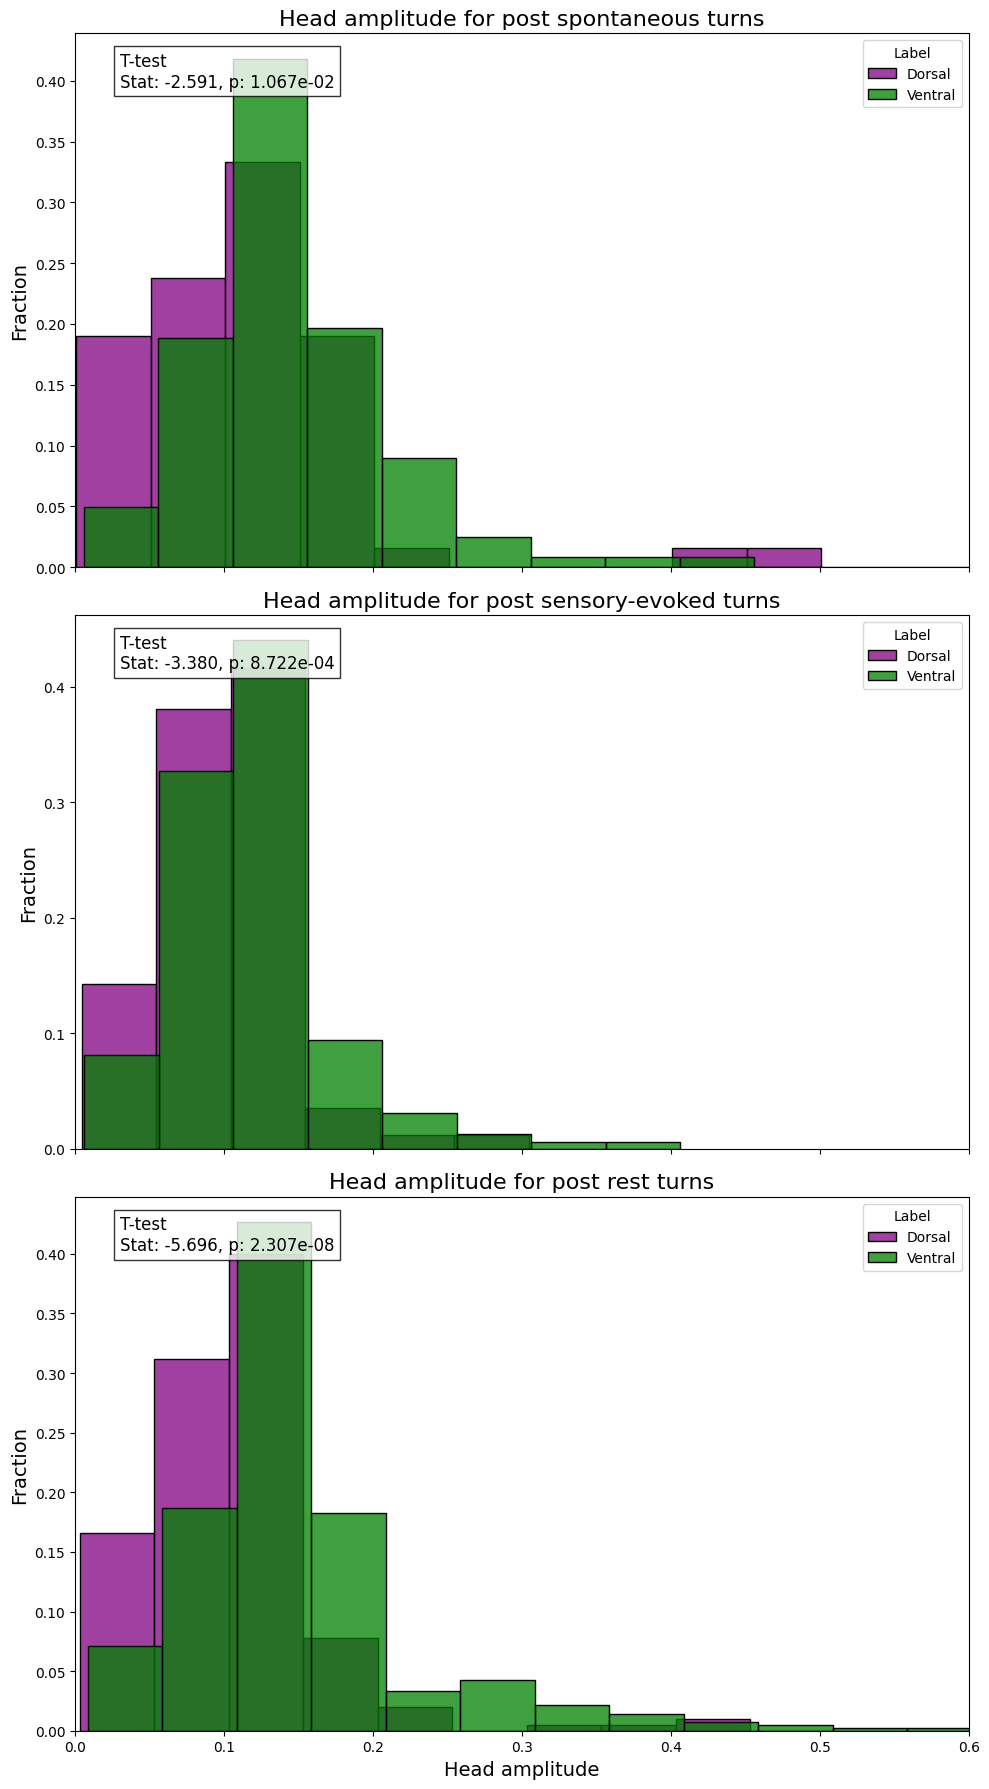

In [125]:
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_histograms_and_test_distributions(df, test="ks"):
    """
    Plots normalized absolute peak value histograms and performs statistical tests 
    to compare dorsal and ventral distributions within each category.

    Parameters:
    - df (pd.DataFrame): Data containing 'peak_value', 'category', and 'peak_label' columns.
    - test (str): Statistical test to use ('ks', 'mannwhitney', or 'ttest').
    """
    # Define colors for dorsal (purple) and ventral (green)
    palette = {'dorsal': 'purple', 'ventral': 'green'}
    
    # Take the absolute value of the peak values
    df['abs_peak_value'] = df['peak_value'].abs()
    
    # Set bin width for consistent binning across all categories
    bin_width = 0.05
    
    # Set up the figure with subplots: one row per category
    categories = df['category'].unique()
    num_categories = len(categories)
    fig, axes = plt.subplots(num_categories, 1, figsize=(10, 6 * num_categories), sharex=True)

    if num_categories == 1:
        axes = [axes]  # Ensure consistency if there's only one category

    # Loop over each category
    for i, category in enumerate(categories):
        # Filter data for the current category
        category_data = df[df['category'] == category]
        dorsal_data = category_data[category_data['peak_label'] == 'dorsal']['abs_peak_value']
        ventral_data = category_data[category_data['peak_label'] == 'ventral']['abs_peak_value']
        
        # Plot normalized histograms
        sns.histplot(dorsal_data, 
                     color=palette['dorsal'], label='Dorsal', ax=axes[i], 
                     binwidth=bin_width, stat="probability")
        sns.histplot(ventral_data, 
                     color=palette['ventral'], label='Ventral', ax=axes[i], 
                     binwidth=bin_width, stat="probability")
        
        # Set title, labels, and legend
        axes[i].set_title(f'Head amplitude for post {category} turns', fontsize=16)
        axes[i].set_xlabel('Head amplitude', fontsize=14)
        axes[i].set_ylabel('Fraction', fontsize=14)
        axes[i].legend(title='Label')
        axes[i].set_xlim(0, 0.6)
        
        # Perform statistical test
        if test == "ks":
            stat, p_value = ks_2samp(dorsal_data, ventral_data)
            test_name = "Kolmogorov-Smirnov Test"
        elif test == "mannwhitney":
            stat, p_value = mannwhitneyu(dorsal_data, ventral_data, alternative='two-sided')
            test_name = "Mann-Whitney U Test"
        elif test == "ttest":
            stat, p_value = ttest_ind(dorsal_data, ventral_data, equal_var=False)
            test_name = "T-test"
        else:
            raise ValueError("Invalid test specified. Choose 'ks', 'mannwhitney', or 'ttest'.")
        
        # Display test results on the plot
        axes[i].text(0.05, 0.9, f"{test_name}\nStat: {stat:.3f}, p: {p_value:.3e}", 
                     transform=axes[i].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
# Assuming `rev_length` is your DataFrame
plot_histograms_and_test_distributions(rev_length, test="ttest")


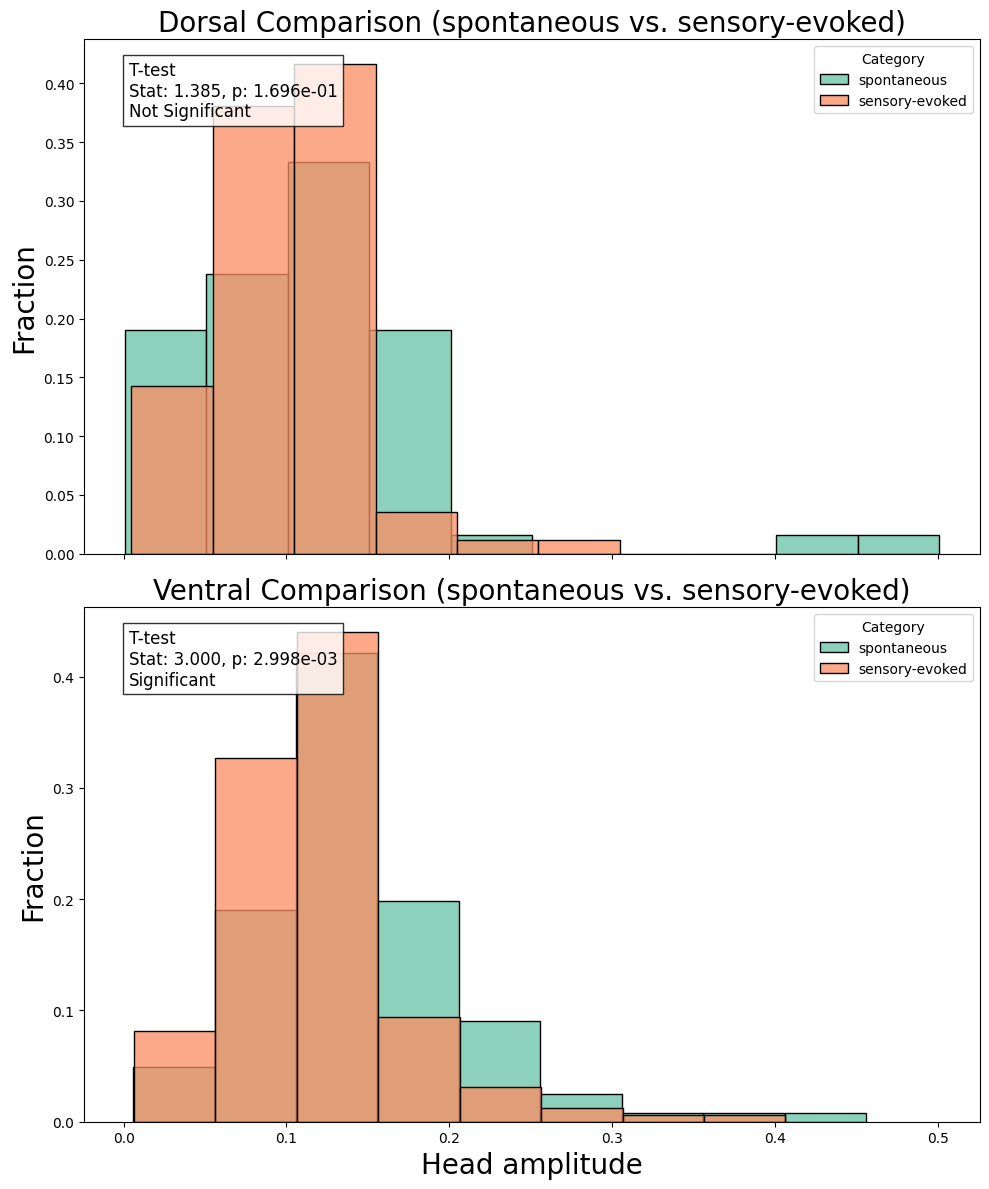

In [28]:
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_and_compare_two_categories(df, category1, category2, test="ks", alpha=0.05):
    """
    Plots normalized absolute peak value histograms and performs statistical tests 
    to compare dorsal and ventral distributions across two specified categories.

    Parameters:
    - df (pd.DataFrame): Data containing 'peak_value', 'category', and 'peak_label' columns.
    - category1 (str): The first category to compare.
    - category2 (str): The second category to compare.
    - test (str): Statistical test to use ('ks', 'mannwhitney', or 'ttest').
    - alpha (float): Significance level for the statistical test.
    """
    # Define colors for dorsal (purple) and ventral (green)
    # palette = {'dorsal': 'purple', 'ventral': 'green'}
    # Set colors using the Set2 palette
    set2_colors = sns.color_palette("Set2", 2)
    # Take the absolute value of the peak values
    df['abs_peak_value'] = df['peak_value'].abs()
    
    # Filter data for the two categories
    df = df[df['category'].isin([category1, category2])]
    
    # Split data into dorsal and ventral
    dorsal_data = df[df['peak_label'] == 'dorsal']
    ventral_data = df[df['peak_label'] == 'ventral']
    
    # Further split dorsal and ventral by categories
    dorsal_cat1 = dorsal_data[dorsal_data['category'] == category1]['abs_peak_value']
    dorsal_cat2 = dorsal_data[dorsal_data['category'] == category2]['abs_peak_value']
    ventral_cat1 = ventral_data[ventral_data['category'] == category1]['abs_peak_value']
    ventral_cat2 = ventral_data[ventral_data['category'] == category2]['abs_peak_value']
    ventral_cat1=ventral_cat1 [ventral_cat1 <0.5]
    ventral_cat2 =ventral_cat2 [ventral_cat2 <0.5]
    # Perform statistical tests
    if test == "ks":
        dorsal_stat, dorsal_p = ks_2samp(dorsal_cat1, dorsal_cat2)
        ventral_stat, ventral_p = ks_2samp(ventral_cat1, ventral_cat2)
        test_name = "Kolmogorov-Smirnov Test"
    elif test == "mannwhitney":
        dorsal_stat, dorsal_p = mannwhitneyu(dorsal_cat1, dorsal_cat2, alternative='two-sided')
        ventral_stat, ventral_p = mannwhitneyu(ventral_cat1, ventral_cat2, alternative='two-sided')
        test_name = "Mann-Whitney U Test"
    elif test == "ttest":
        dorsal_stat, dorsal_p = ttest_ind(dorsal_cat1, dorsal_cat2, equal_var=False)
        ventral_stat, ventral_p = ttest_ind(ventral_cat1, ventral_cat2, equal_var=False)
        test_name = "T-test"
    else:
        raise ValueError("Invalid test specified. Choose 'ks', 'mannwhitney', or 'ttest'.")
    
    # Determine significance
    dorsal_significance = "Significant" if dorsal_p < alpha else "Not Significant"
    ventral_significance = "Significant" if ventral_p < alpha else "Not Significant"
    
    # Set up the figure
    fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

    # Plot dorsal distributions
    sns.histplot(dorsal_cat1, color=set2_colors[0], label=category1, 
                 ax=axes[0], binwidth=0.05, stat="probability")
    sns.histplot(dorsal_cat2, color=set2_colors[1], label= category2, 
                 ax=axes[0], binwidth=0.05, stat="probability")
    axes[0].set_title(f'Dorsal Comparison ({category1} vs. {category2})', fontsize=20)
    axes[0].set_xlabel('Head amplitude', fontsize=20)
    axes[0].set_ylabel('Fraction', fontsize=20)
    axes[0].legend(title='Category')
    axes[0].text(0.05, 0.85, f"{test_name}\nStat: {dorsal_stat:.3f}, p: {dorsal_p:.3e}\n{dorsal_significance}",  transform=axes[0].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

    # Plot ventral distributions
    sns.histplot(ventral_cat1, color=set2_colors[0], label=category1, 
                 ax=axes[1], binwidth=0.05, stat="probability")
    sns.histplot(ventral_cat2, color=set2_colors[1], label=category2, 
                 ax=axes[1], binwidth=0.05, stat="probability")
    axes[1].set_title(f'Ventral Comparison ({category1} vs. {category2})', fontsize=20)
    axes[1].set_xlabel('Head amplitude', fontsize=20)
    axes[1].set_ylabel('Fraction', fontsize=20)
    axes[1].legend(title='Category')
    axes[1].text(0.05, 0.85, f"{test_name}\nStat: {ventral_stat:.3f}, p: {ventral_p:.3e}\n{ventral_significance}",transform=axes[1].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()
plot_and_compare_two_categories(rev_length, category1='spontaneous', category2='sensory-evoked', test="ttest")

Shapiro-Wilk Test (spontaneous): p = 0.0000
Shapiro-Wilk Test (sensory-evoked): p = 0.0000
Mann-Whitney U Test: stat = 24458.0000, p = 1.1832e-01 (Not Significant)


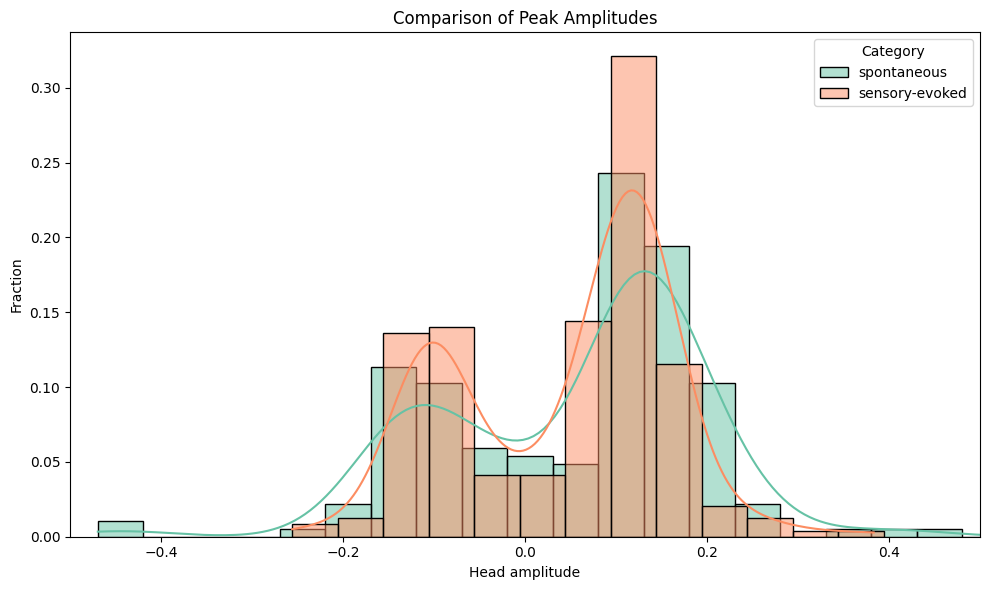

In [129]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind, shapiro

def compare_peak_amplitudes(df, categories_to_compare=('spontaneous', 'sensory-evoked')):
    # Filter data for the selected categories
    df_filtered = df[df['category'].isin(categories_to_compare)]
    
    # Separate peak values for the two categories
    category1, category2 = categories_to_compare
    peak_cat1 = df_filtered[df_filtered['category'] == category1]['peak_value']
    peak_cat2 = df_filtered[df_filtered['category'] == category2]['peak_value']

    # Set colors using the Set2 palette
    set2_colors = sns.color_palette("Set2", 2)
    
    # Perform normality tests (Shapiro-Wilk)
    _, p_cat1 = shapiro(peak_cat1)
    _, p_cat2 = shapiro(peak_cat2)
    
    # Display normality test results
    print(f"Shapiro-Wilk Test ({category1}): p = {p_cat1:.4f}")
    print(f"Shapiro-Wilk Test ({category2}): p = {p_cat2:.4f}")
    
    # Use Mann-Whitney U Test (non-parametric) for unequal sample sizes
    stat, p_value = mannwhitneyu(peak_cat1, peak_cat2, alternative='two-sided')
    
    # Display statistical test results
    print(f"Mann-Whitney U Test: stat = {stat:.4f}, p = {p_value:.4e} {'(Significant)' if p_value < 0.05 else '(Not Significant)'}")
    
    # Plot the combined histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(peak_cat1, color=set2_colors[0], label=category1, kde=True, binwidth=0.05, stat='probability')
    sns.histplot(peak_cat2, color=set2_colors[1], label=category2, kde=True, binwidth=0.05, stat='probability')
    plt.xlim(-0.5,0.5)
    plt.title('Comparison of Peak Amplitudes')
    plt.xlabel('Head amplitude')
    plt.ylabel('Fraction')
    plt.legend(title='Category')
    plt.tight_layout()
    plt.rcParams['svg.fonttype'] = 'none'
# Save the figure
    plt.savefig('Head_Peak_amplitude.svg', format='svg', dpi=300)
    plt.show()
compare_peak_amplitudes(rev_length)

Animals with data in both categories: 23

Shapiro-Wilk on paired differences: p = 0.5599
Paired t-test: stat = 1.8706, p = 7.4763e-02 (Not Significant)


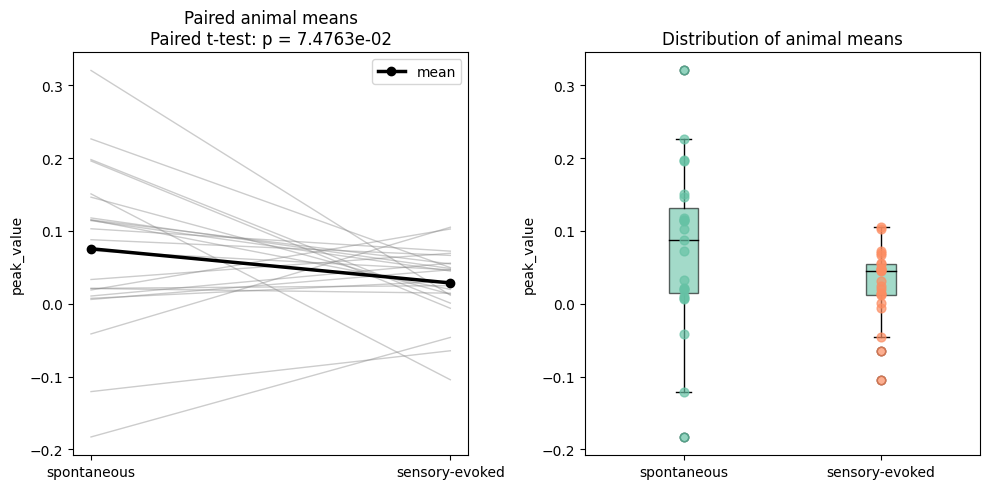

In [130]:
def compare_peak_amplitudes(df, metric='peak_value', categories_to_compare=('spontaneous', 'sensory-evoked')):
    """
    Compare a metric between two categories using animal-level aggregation
    to account for non-independence (multiple runs per worm).
    
    Each worm contributes exactly one mean value per category,
    then a Wilcoxon signed-rank test is run on the paired animal means.
    """
    category1, category2 = categories_to_compare

    # Aggregate to one mean per animal per category
    animal_means = (
        df[df['category'].isin(categories_to_compare)]
        .groupby(['worm', 'category'])[metric]
        .mean()
        .reset_index()
    )

    # Keep only animals that have data in BOTH categories (paired test requires this)
    paired = animal_means.pivot(index='worm', columns='category', values=metric).dropna()

    n_pairs = len(paired)
    print(f"Animals with data in both categories: {n_pairs}")

    if n_pairs < 3:
        print("Too few paired animals for a reliable test.")
        return

    vals1 = paired[category1].values
    vals2 = paired[category2].values

    # Shapiro-Wilk on the paired differences
    diffs = vals1 - vals2
    _, p_norm = shapiro(diffs)
    print(f"\nShapiro-Wilk on paired differences: p = {p_norm:.4f}")

    if p_norm > 0.05:
        # Differences are normal → paired t-test
        from scipy.stats import ttest_rel
        stat, p_value = ttest_rel(vals1, vals2)
        test_name = "Paired t-test"
    else:
        # Non-normal → Wilcoxon signed-rank (paired non-parametric)
        from scipy.stats import wilcoxon
        stat, p_value = wilcoxon(vals1, vals2)
        test_name = "Wilcoxon signed-rank"

    print(f"{test_name}: stat = {stat:.4f}, p = {p_value:.4e} "
          f"{'(Significant)' if p_value < 0.05 else '(Not Significant)'}")

    # --- Plot ---
    set2_colors = sns.color_palette("Set2", 2)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Left: paired lines (one line per animal)
    ax = axes[0]
    for _, row in paired.iterrows():
        ax.plot([category1, category2], [row[category1], row[category2]],
                color='gray', alpha=0.4, lw=1)
    ax.plot([category1, category2], [vals1.mean(), vals2.mean()],
            color='black', lw=2.5, marker='o', label='mean')
    ax.set_ylabel(metric)
    ax.set_title(f"Paired animal means\n{test_name}: p = {p_value:.4e}")
    ax.legend()

    # Right: distribution of the per-animal means
    ax = axes[1]
    ax.boxplot([vals1, vals2], labels=[category1, category2],
               patch_artist=True,
               boxprops=dict(facecolor=set2_colors[0], alpha=0.6),
               medianprops=dict(color='black'))
    for i, vals in enumerate([vals1, vals2]):
        ax.scatter([i + 1] * len(vals), vals, color=set2_colors[i],
                   zorder=3, alpha=0.7, s=40)
    ax.set_ylabel(metric)
    ax.set_title("Distribution of animal means")

    plt.tight_layout()
    plt.show()

    return paired, p_value


# --- Usage ---
paired_df, p = compare_peak_amplitudes(rev_length, metric='peak_value')

In [54]:

plt.figure(figsize=(10, 6))
    
    # Create the violin plot for run lengths
sns.violinplot(x='target', y='Angular_speed', data=rev_length, palette='Set2', inner=None)
    
    # Overlay individual points using stripplot
sns.stripplot(x='target', y='Angular_speed', data=rev_length, color='k', size=5, jitter=True, alpha=0.7)
    
    # Add title and labels
plt.title('Run Lengths by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Rev Length (s)', fontsize=12)
    
    # Display the plot
plt.show()

ValueError: Could not interpret input 'target'

<Figure size 1000x600 with 0 Axes>

In [81]:
import scipy.stats as stats

# Perform pairwise Mann-Whitney U tests
def perform_pairwise_mannwhitney(df):
    category_1 = df[df['category'] == 'spontaneous']['run_length']
    category_2 = df[df['category'] == 'sensory-evoked']['run_length']
    category_3 = df[df['category'] == 'rest']['run_length']

    # Pairwise comparisons
    mw_1_2 = stats.mannwhitneyu(category_1, category_2)
    mw_1_3 = stats.mannwhitneyu(category_1, category_3)
    mw_2_3 = stats.mannwhitneyu(category_2, category_3)

    print(f"Pairwise Mann-Whitney U Tests:")
    print(f"Category 1 vs Category 2: p-value = {mw_1_2.pvalue}")
    print(f"Category 1 vs Category 3: p-value = {mw_1_3.pvalue}")
    print(f"Category 2 vs Category 3: p-value = {mw_2_3.pvalue}")


# Perform pairwise Mann-Whitney U tests
perform_pairwise_mannwhitney(rev_length)


Kruskal-Wallis Test:
Statistic = 35.42612715581873, p-value = 2.0291503650207687e-08
Pairwise Mann-Whitney U Tests:
Category 1 vs Category 2: p-value = 0.3592655257446379
Category 1 vs Category 3: p-value = 0.00010267326772943355
Category 2 vs Category 3: p-value = 9.763189237944417e-08


In [84]:
from scipy import stats

# Define your categories
hit_reversals = 'sensory-evoked' # Ensure this matches the string used in your DataFrame
rest = 'spontaneous'  # Ensure this matches the string used in your DataFrame

# Filter run lengths based on categories
run_lengths_cat1 = rev_length[rev_length['category'] ==hit_reversals ]['run_length']
run_lengths_cat2 = rev_length[rev_length['category'] ==rest ]['run_length']

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(run_lengths_cat1, run_lengths_cat2, nan_policy='omit',equal_var=False)

# Print the results
print(f"T-test results:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")


T-test results:
t-statistic: 0.6948, p-value: 0.4876


In [120]:
import numpy as np
import pandas as pd
from itertools import combinations

def animal_aware_permutation_test(
    df: pd.DataFrame,
    metric: str,
    cat_col: str = "category",
    animal_col: str = "worm",
    cat_a: str = "spontaneous",
    cat_b: str = "sensory-evoked",
    n_perm: int = 5000,
    rng_seed: int = 42,
):
    """
    Two-sample permutation test that shuffles category labels *within*
    each animal, preserving the repeated-measures structure.

    Returns
    -------
    dict with keys: observed_stat, p_value, null_distribution
    """
    rng = np.random.default_rng(rng_seed)

    # Keep only the two categories of interest, drop NaN in metric
    sub = df[df[cat_col].isin([cat_a, cat_b])].dropna(subset=[metric]).copy()

    def mean_diff(data):
        """Mean(cat_a) - Mean(cat_b), averaged across animals (gives each animal equal weight)."""
        animal_diffs = []
        for animal, grp in data.groupby(animal_col):
            a_vals = grp.loc[grp[cat_col] == cat_a, metric].values
            b_vals = grp.loc[grp[cat_col] == cat_b, metric].values
            if len(a_vals) > 0 and len(b_vals) > 0:
                animal_diffs.append(a_vals.mean() - b_vals.mean())
        return np.mean(animal_diffs) if animal_diffs else np.nan

    observed_stat = mean_diff(sub)

    # Build null distribution by shuffling labels within each animal
    null_dist = np.empty(n_perm)
    for i in range(n_perm):
        perm = sub.copy()
        for animal, grp in sub.groupby(animal_col):
            shuffled_labels = rng.permutation(grp[cat_col].values)
            perm.loc[grp.index, cat_col] = shuffled_labels
        null_dist[i] = mean_diff(perm)

    # Two-sided p-value
    p_value = np.mean(np.abs(null_dist) >= np.abs(observed_stat))

    return {
        "metric": metric,
        "observed_stat": observed_stat,
        "p_value": p_value,
        "null_distribution": null_dist,
    }


def run_comparison(df, metric, n_perm=5000):
    """
    Run animal-aware permutation test for a given metric,
    comparing spontaneous vs sensory-evoked.
    """
    if metric not in df.columns:
        raise ValueError(f"'{metric}' not found in dataframe. Available: {list(df.columns)}")

    print(f"Running permutation test for '{metric}' (n={n_perm})...")

    res = animal_aware_permutation_test(
        df,
        metric=metric,
        cat_a="spontaneous",
        cat_b="sensory-evoked",
        n_perm=n_perm,
    )

    print(f"  observed diff : {res['observed_stat']:.4f}  (spontaneous − sensory-evoked)")
    print(f"  p-value       : {res['p_value']:.4f}")

    return res

In [121]:
# --- Usage ---
result = run_comparison(rev_length, metric="mean_speed")

Running permutation test for 'mean_speed' (n=5000)...
  observed diff : -0.0142  (spontaneous − sensory-evoked)
  p-value       : 0.0062


In [127]:
run_comparison(rev_length, metric="abs_peak_value")

Running permutation test for 'abs_peak_value' (n=5000)...
  observed diff : 0.0279  (spontaneous − sensory-evoked)
  p-value       : 0.0018


{'metric': 'abs_peak_value',
 'observed_stat': 0.02792291915472663,
 'p_value': 0.0018,
 'null_distribution': array([-0.01549632,  0.02058161, -0.00856137, ..., -0.00907149,
         0.01707885, -0.00416048])}

In [123]:
run_comparison(rev_length, metric="run_length")

Running permutation test for 'run_length' (n=5000)...
  observed diff : 0.5155  (spontaneous − sensory-evoked)
  p-value       : 0.0794


{'metric': 'run_length',
 'observed_stat': 0.5154712266988483,
 'p_value': 0.0794,
 'null_distribution': array([-0.1067755 ,  0.3177619 ,  0.33626915, ..., -0.02020386,
        -0.38765548,  0.37797536])}

In [88]:
import scipy.stats as stats

# Perform pairwise Kolmogorov-Smirnov Test
def perform_ks_test(df):
    # Extract run lengths for each category
    category_1 = df[df['category'] == 'spontaneous']['run_length']
    category_2 = df[df['category'] == 'sensory-evoked']['run_length']
    category_3 = df[df['category'] == 'rest']['run_length']
    
    # Perform KS test between pairs of categories
    ks_stat_1_2, p_value_1_2 = stats.ks_2samp(category_1, category_2)
    ks_stat_1_3, p_value_1_3 = stats.ks_2samp(category_1, category_3)
    ks_stat_2_3, p_value_2_3 = stats.ks_2samp(category_2, category_3)

    print(f"KS Test (Baseline vs Hit Reversals):\nStatistic = {ks_stat_1_2}, p-value = {p_value_1_2}")
    print(f"KS Test (Baseline vs Rest):\nStatistic = {ks_stat_1_3}, p-value = {p_value_1_3}")
    print(f"KS Test (Hit Reversals vs Rest):\nStatistic = {ks_stat_2_3}, p-value = {p_value_2_3}")
    
    return {
        'Baseline vs Hit Reversals': (ks_stat_1_2, p_value_1_2),
        'Baseline vs Rest': (ks_stat_1_3, p_value_1_3),
        'Hit Reversals vs Rest': (ks_stat_2_3, p_value_2_3)
    }
perform_ks_test(rev_length)

KS Test (Baseline vs Hit Reversals):
Statistic = 0.10225781336892448, p-value = 0.20345871824586187
KS Test (Baseline vs Rest):
Statistic = 0.16562299224739796, p-value = 0.0006662315554772921
KS Test (Hit Reversals vs Rest):
Statistic = 0.19366998623910053, p-value = 3.055272806414685e-06


{'Baseline vs Hit Reversals': (0.10225781336892448, 0.20345871824586187),
 'Baseline vs Rest': (0.16562299224739796, 0.0006662315554772921),
 'Hit Reversals vs Rest': (0.19366998623910053, 3.055272806414685e-06)}

In [14]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Prepare the data for ANOVA
df = rev_length[['run_length', 'category']]  # Make sure your DataFrame has run lengths and categories

# Fit the model
model = ols('run_length ~ C(category)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Tukey's HSD
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=df['run_length'], groups=df['category'], alpha=0.05)

print(tukey)


       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
     baseline hit reversals   0.1629 0.6591 -0.2764  0.6022  False
     baseline          rest  -0.7772    0.0 -1.1536 -0.4008   True
hit reversals          rest  -0.9401    0.0   -1.28 -0.6002   True
------------------------------------------------------------------


In [ ]:
#use this if forward speed needs to ne
# df_speed=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\centroid_speed.csv",header=None)
# rev_length=find_runlengths_and_classify(manual_annotation,head_curvature,df_speed.T)

In [23]:
def trig_average(df, results_df=rev_length, min_win=30, max_win=30, fps=10):
    all_triggered_speeds = []  # To store triggered speeds for all worms
    annotations = []           # To store corresponding annotations (hit_reversals or not)
    groups = []                # To store the worm (group) information

    for worm in df.index:  # Loop through each row (worm)
        speed = df.loc[worm]  # Get the speed data for the worm (row)
        
        # Get the trigger points (start indices) for the current worm from results_df
        worm_trigger_points = results_df[results_df['worm'] == worm]['start_index']

        for trigger_point in worm_trigger_points:

            # Calculate the frame indices for the window around the trigger point
            window_start = trigger_point - min_win*fps
            window_end = trigger_point + max_win*fps

            # Ensure the window indices are within bounds of the speed data
            if window_start >= 0 and window_end < len(speed):
                # Extract the speeds within the window
                window_speeds = speed[window_start:window_end].values
                
                # Ensure window_speeds has the correct length (min_win + max_win)
                if len(window_speeds) == (min_win + max_win)*fps:
                    # Append the window speeds, annotation, and group information
                    all_triggered_speeds.append(window_speeds)
                    
                    # Check if this is a hit reversal and assign 1 if so, otherwise 0
                    category = results_df[results_df['worm'] == worm].loc[
                        results_df['start_index'] == trigger_point, 'category'].values[0]
                    annotation = 1 if category == 'sensory-evoked' else 0
                    annotations.append(annotation)
                    
                    # Append the group (worm) information
                    groups.append(worm)
    
    # Convert the results to a DataFrame
    triggered_speeds_df = pd.DataFrame(all_triggered_speeds)
    
    # Append annotations and group (worm) columns
    triggered_speeds_df['annotation'] = annotations
    triggered_speeds_df['worm'] = groups
    
    return triggered_speeds_df


In [91]:
def trig_average(df, results_df=rev_length, min_win=30, max_win=30, fps=10):
    all_triggered_speeds = []  # To store triggered speeds for all worms
    annotations = []           # To store corresponding annotations (sensory-evoked, spontaneous, or others)
    groups = []                # To store the worm (group) information

    for worm in df.index:  # Loop through each row (worm)
        speed = df.loc[worm]  # Get the speed data for the worm (row)
        
        # Get the trigger points (start indices) for the current worm from results_df
        worm_trigger_points = results_df[results_df['worm'] == worm]['start_index']

        for trigger_point in worm_trigger_points:

            # Calculate the frame indices for the window around the trigger point
            window_start = trigger_point - min_win * fps
            window_end = trigger_point + max_win * fps

            # Ensure the window indices are within bounds of the speed data
            if window_start >= 0 and window_end < len(speed):
                # Extract the speeds within the window
                window_speeds = speed[window_start:window_end].values
                
                # Ensure window_speeds has the correct length (min_win + max_win)
                if len(window_speeds) == (min_win + max_win) * fps:
                    # Append the window speeds, annotation, and group information
                    all_triggered_speeds.append(window_speeds)
                    
                    # Determine the category and set the annotation
                    filtered_df = results_df[(results_df['worm'] == worm) & 
                                             (results_df['start_index'] == trigger_point)]
                    if not filtered_df.empty:
                        category = filtered_df['category'].values[0]
                        if category == 'sensory-evoked':
                            annotation = 1
                        elif category == 'spontaneous':
                            annotation = 0
                        else:
                            annotation = 2
                    else:
                        annotation = 2  # Default to 2 if no match found
                    annotations.append(annotation)
                    
                    # Append the group (worm) information
                    groups.append(worm)
    
    # Convert the results to a DataFrame
    triggered_speeds_df = pd.DataFrame(all_triggered_speeds)
    
    # Append annotations and group (worm) columns
    triggered_speeds_df['annotation'] = annotations
    triggered_speeds_df['worm'] = groups
    
    return triggered_speeds_df


In [92]:
df_trig_speed=trig_average(df_speed)
df_trig_ang_speed=trig_average(df_angular_speed)
df_trig_head_freq=trig_average(df_head_freq.T)
df_trig_curvature=trig_average(df_curvature.T)
df_trig_rev_run=trig_average(df_rev_run.T/10)
df_trig_roam_dwell=trig_average(df_roam_dwell)
df_trig_head_curvature=trig_average(head_curvature.T)

In [93]:
df_trig_speed

,0,1,2,3,4,5,6,7,8,9,...,592,593,594,595,596,597,598,599,annotation,worm
0,0.225840,0.158420,0.109420,0.102580,0.194260,0.171830,0.150300,0.134650,0.151170,0.111830,...,0.065803,0.103320,0.109490,0.114590,0.070349,0.073389,0.064327,0.070036,0,0
1,0.164010,0.155710,0.175680,0.206020,0.198150,0.206020,0.230110,0.158090,0.186120,0.173620,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,NaN,NaN,NaN,NaN,NaN,0.090377,0.072533,0.064133,0.057000,0.036359,...,0.051420,0.072533,0.056436,0.065803,0.112700,0.107350,0.115970,0.121240,0,0
3,0.089961,0.078237,0.086954,0.089644,0.058258,0.071421,0.072007,0.081056,0.070711,0.038471,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,0.078772,0.076844,0.062241,0.032757,0.071568,0.058249,0.067779,0.073736,NaN,NaN,...,0.067779,0.063285,0.076000,0.075954,0.090028,0.093059,0.105690,0.093434,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1033,0.194250,0.161480,0.174620,0.184450,0.211990,0.200410,0.170140,0.127320,0.195820,0.161010,...,0.188220,0.166210,0.192610,0.159480,0.160520,0.172710,0.106940,0.166020,0,24
1034,0.284200,0.264880,0.205880,0.231900,0.187610,0.210040,0.227010,0.195870,0.241120,0.241120,...,0.217330,0.171450,0.172810,0.134650,0.180340,0.191670,0.183930,0.209890,0,24
1035,0.071421,0.080006,0.077369,0.120150,0.132140,0.129440,0.151160,0.151120,0.158110,0.145120,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,24
1036,0.250950,0.263180,0.174750,0.200170,0.196770,0.148810,0.142040,0.143220,0.138660,0.120280,...,0.167540,0.183830,0.214980,0.206810,0.156850,0.202090,0.214980,0.213550,1,24


In [94]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_trigger_average(df_trig_speed, min_win=30, max_win=30, fps=10):
    """
    Plots the trigger average speed for different categories in different colors.

    Parameters:
        triggered_speeds_df (pd.DataFrame): DataFrame containing triggered speeds, annotations, and worms.
        min_win (int): Minimum window size (in seconds) before the trigger point.
        max_win (int): Maximum window size (in seconds) after the trigger point.
        fps (int): Frames per second of the data.
    """
    # Define colors for each annotation category
    set2_colors = plt.cm.Set2.colors 
    category_colors = {
        1: set2_colors[1],  # Sensory-evoked
        0: set2_colors[0],  # Spontaneous
        # 2: set2_colors[2],  # Other (example)
    }
    category_labels = {
        0: 'Spontaneous',
        1: 'Sensory-Evoked',
        # 2: 'Other'
    }
    
    # Define the time window for the x-axis
    time_window = np.linspace(-min_win, max_win, num=(min_win + max_win) * fps)

    # Initialize the plot
    plt.figure(figsize=(9, 6))
    
    # Plot for each category
    for category, color in category_colors.items():
        # Filter speeds by category
        category_data =df_trig_speed[df_trig_speed['annotation'] == category]
        
        if not category_data.empty:
            # Calculate the mean and standard error
            speeds = category_data.iloc[:, :-2].values  # Exclude 'annotation' and 'worm' columns
            mean_speed = np.nanmean(speeds, axis=0)
            sem_speed = np.nanstd(speeds, axis=0) / np.sqrt(np.sum(~np.isnan(speeds), axis=0))

            # Plot mean with shaded error band
            plt.plot(time_window, mean_speed, label=category_labels[category], color=color)
            plt.fill_between(time_window, mean_speed - sem_speed, mean_speed + sem_speed, color=color, alpha=0.3)

    # Add a vertical line at the trigger point
    plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Reversal onset')
    
    # Customize the plot
    plt.xlim(-30, 30)  # Set x-axis range
    plt.title('Trigger Average Speeds for Different Categories')
    plt.xlabel('Time (s)')
    plt.ylabel('Speed (mm/s)')
    plt.legend()
    plt.tight_layout()
    plt.rcParams['svg.fonttype'] = 'none'
# Save the figure
    # plt.savefig('Reversal_triggered_Speed.svg', format='svg', dpi=300)
    plt.show()
    


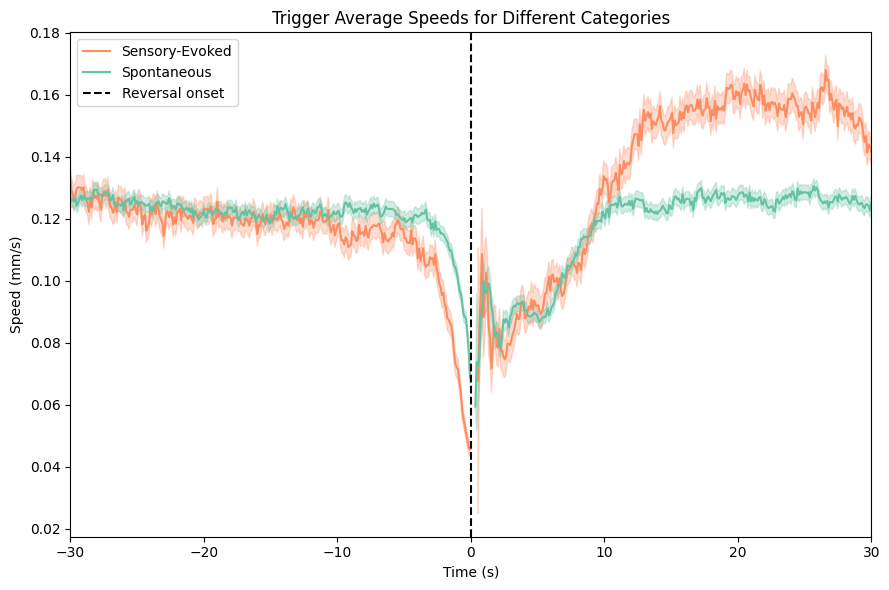

In [95]:
# Assuming `triggered_speeds_df` is the output from `trig_average`
plot_trigger_average(df_trig_speed, min_win=30, max_win=30, fps=10)


In [96]:
df=pd.DataFrame()
# df['speed']=df_trig_speed.loc[:,401:599].mean(axis=1, skipna=True)
df['speed']=df_trig_speed.loc[:,250:300].mean(axis=1, skipna=True)
df['Angular_speed']=df_trig_ang_speed.loc[:,301:400].mean(axis=1, skipna=True)
df['curvature']=df_trig_curvature.loc[:,301:400].mean(axis=1, skipna=True)
df['head_frequency']=df_trig_head_freq.loc[:,301:400].mean(axis=1, skipna=True)
df['rev_run']=df_trig_rev_run.loc[:,301:400].mean(axis=1, skipna=True)
df['roam_dwell']=df_trig_roam_dwell.loc[:,301:400].mean(axis=1, skipna=True)
df['head_curvature']=df_trig_head_curvature.loc[:,301:400].mean(axis=1, skipna=True)
df['group']=df_trig_speed.iloc[:,-1]
df['target']=df_trig_speed.iloc[:,-2]
df

,speed,Angular_speed,curvature,head_frequency,rev_run,roam_dwell,head_curvature,group,target
0,0.103678,8.190092,31.478555,1.71,1.216327,1.00,-0.008383,0,0
1,0.123755,5.800058,33.330019,1.65,2.950000,1.00,-0.009873,0,0
2,0.069547,6.393494,48.541079,0.83,2.600000,0.15,0.008467,0,0
3,0.058356,5.936166,36.613671,1.59,3.050000,1.00,0.027478,0,0
4,0.090965,5.274384,46.266658,1.14,2.500000,1.00,-0.029265,0,0
...,...,...,...,...,...,...,...,...,...
1033,0.068787,5.770264,36.160610,1.72,3.200000,1.00,0.006435,24,0
1034,0.120570,5.623712,31.716801,1.72,4.250000,1.00,-0.018703,24,0
1035,0.149027,5.336824,35.417311,2.26,3.300000,1.00,-0.000999,24,0
1036,0.180465,5.410326,39.146595,1.78,3.200000,1.00,-0.016233,24,1


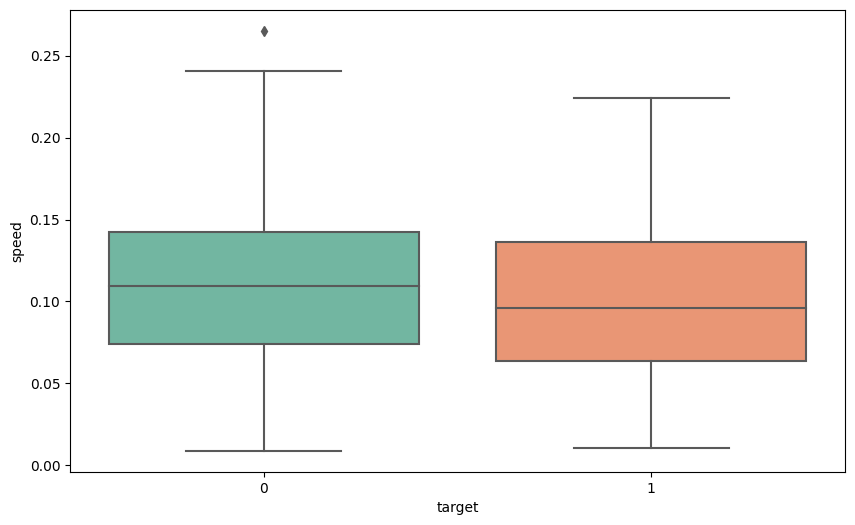

In [86]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='speed', data=df, palette='Set2')
plt.show()

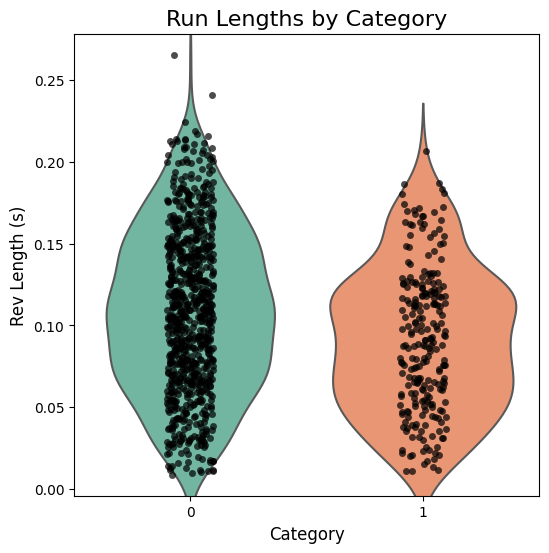

In [97]:
plt.figure(figsize=(6, 6))
    
    # Create the violin plot for run lengths
sns.violinplot(x='target', y='speed', data=df, palette='Set2', inner=None)
    
    # Overlay individual points using stripplot
sns.stripplot(x='target', y='speed', data=df, color='k', size=5, jitter=True, alpha=0.7)
    
    # Add title and labels
plt.title('Run Lengths by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Rev Length (s)', fontsize=12)
    
    # Display the plot
plt.show()

In [98]:
def animal_aware_permutation_test(
    df: pd.DataFrame,
    metric: str,
    cat_col: str = "target",
    animal_col: str = "group",
    cat_a: int = 0,
    cat_b: int = 1,
    n_perm: int = 5000,
    rng_seed: int = 42,
):
    """
    Two-sample permutation test that shuffles category labels *within*
    each animal, preserving the repeated-measures structure.

    Returns
    -------
    dict with keys: observed_stat, p_value, null_distribution
    """
    rng = np.random.default_rng(rng_seed)

    # Keep only the two categories of interest, drop NaN in metric
    sub = df[df[cat_col].isin([cat_a, cat_b])].dropna(subset=[metric]).copy()

    def mean_diff(data):
        """Mean(cat_a) - Mean(cat_b), averaged across animals (gives each animal equal weight)."""
        animal_diffs = []
        for animal, grp in data.groupby(animal_col):
            a_vals = grp.loc[grp[cat_col] == cat_a, metric].values
            b_vals = grp.loc[grp[cat_col] == cat_b, metric].values
            if len(a_vals) > 0 and len(b_vals) > 0:
                animal_diffs.append(a_vals.mean() - b_vals.mean())
        return np.mean(animal_diffs) if animal_diffs else np.nan

    observed_stat = mean_diff(sub)

    # Build null distribution by shuffling labels within each animal
    null_dist = np.empty(n_perm)
    for i in range(n_perm):
        perm = sub.copy()
        for animal, grp in sub.groupby(animal_col):
            shuffled_labels = rng.permutation(grp[cat_col].values)
            perm.loc[grp.index, cat_col] = shuffled_labels
        null_dist[i] = mean_diff(perm)

    # Two-sided p-value
    p_value = np.mean(np.abs(null_dist) >= np.abs(observed_stat))

    return {
        "metric": metric,
        "observed_stat": observed_stat,
        "p_value": p_value,
        "null_distribution": null_dist,
    }


def run_comparison(df, metric, n_perm=5000):
    """
    Run animal-aware permutation test for a given metric,
    comparing spontaneous vs sensory-evoked.
    """
    if metric not in df.columns:
        raise ValueError(f"'{metric}' not found in dataframe. Available: {list(df.columns)}")

    print(f"Running permutation test for '{metric}' (n={n_perm})...")

    res = animal_aware_permutation_test(
        df,
        metric=metric,
        cat_a=0,
        cat_b=1,
        n_perm=n_perm,
    )

    print(f"  observed diff : {res['observed_stat']:.4f}  (spontaneous − sensory-evoked)")
    print(f"  p-value       : {res['p_value']:.4f}")

    return res



In [99]:
run_comparison(df,'speed')

Running permutation test for 'speed' (n=5000)...
  observed diff : 0.0180  (spontaneous − sensory-evoked)
  p-value       : 0.0000


{'metric': 'speed',
 'observed_stat': 0.01801442975542316,
 'p_value': 0.0,
 'null_distribution': array([0.00183661, 0.0005012 , 0.00116833, ..., 0.00395199, 0.00467455,
        0.00196311])}

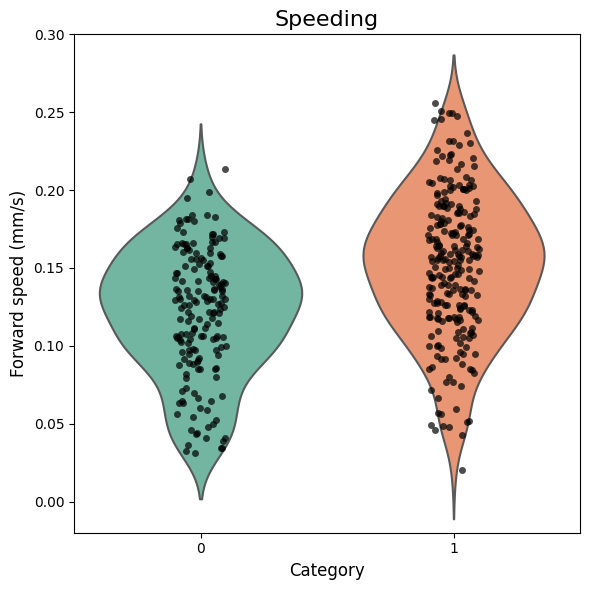

In [254]:
df_filtered = df[df['target'].isin([0, 1])]

plt.figure(figsize=(6, 6))

sns.violinplot(
    x='target',
    y='speed',
    data=df_filtered,
    palette='Set2',
    inner=None
)

sns.stripplot(
    x='target',
    y='speed',
    data=df_filtered,
    color='k',
    size=5,
    jitter=True,
    alpha=0.7
)

# Expand y-axis slightly
ymin = df_filtered['speed'].min()
ymax = df_filtered['speed'].max()
plt.ylim(-0.02,0.3)

plt.title('Speeding', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Forward speed (mm/s)', fontsize=12)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
# Save the figure
plt.savefig('Speeding_spontvsevoked.svg', format='svg', dpi=300)
plt.show()

In [135]:
from scipy import stats


# Filter run lengths based on categories
run_lengths_cat1 = df[df['target'] ==0 ]['speed']
run_lengths_cat2 = df[df['target'] ==1 ]['speed']

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(run_lengths_cat1, run_lengths_cat2, nan_policy='omit',equal_var=False)

# Print the results
print(f"T-test results:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")


T-test results:
t-statistic: -6.9954, p-value: 0.0000


In [26]:
def plot_permutation_results(perm_scores, score, pvalue, neuron):
    fig, ax = plt.subplots()

    # Dynamically calculate bins for the histogram
    bins = max(10, len(perm_scores) // 20)
    
    ax.hist(perm_scores, bins=bins, density=True, color="tab:purple", alpha=0.7)
    ax.axvline(score, ls="--", color="k", label=f"Score: {score:.2f}\n(p-value: {pvalue:.3f})")
    
    ax.set_xlabel("Accuracy score")
    ax.set_ylabel("Density")
    
    # Adding text annotation dynamically
    ax.legend(loc="upper right")
    
    # Save plot before showing to avoid distortions
    # file_name = f"permutation_test_{neuron}.svg"
    # plt.savefig(file_name, format='svg')
    plt.show()


In [28]:
from numpy import mean
from numpy import std
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.model_selection import permutation_test_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
warnings.filterwarnings("ignore")
def single_lda(data):
    dg = pd.DataFrame(index=data.columns.drop(['target','group']),columns=['mean_accuracy','std','mean_score','perm_accuaracy','p-value'])
    for neuron in data.columns.drop(['target','group']):
        ind_nan=data[neuron].isna()
        ind=ind_nan[ind_nan==False].index
        X=data[[neuron]].dropna()
        y =data.loc[ind,'target']
        groups=data.loc[ind,'group']
            
        model= LinearDiscriminantAnalysis()
        #model= LogisticRegression()
        model.fit(X,y)
        cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=100, random_state=None)
        # cv= StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=0)
        #cv=GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv=StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        # logo = LeaveOneGroupOut()
        # n_splits=logo.get_n_splits(X, y, groups)
        # cv=logo
        
        scores, perm_scores, pvalue = permutation_test_score(model, X, y, scoring="accuracy", cv=cv, groups=groups,n_permutations=100)
        cv_scores = cross_val_score(model, X, y, scoring="f1_weighted", cv=cv,groups=groups,n_jobs=-1)
        print('Mean Accuracy: %.3f (%.3f)' % (mean(scores), std(cv_scores)))
        #print(scores)
        m=(mean(scores))
        s=(std(cv_scores))
        perm_mean_score=(mean(perm_scores))
        

        plot_permutation_results(perm_scores, m, pvalue, neuron)

        # Log the results
        dg.loc[neuron, 'mean_accuracy'] = m
        dg.loc[neuron, 'mean_score'] = mean(cv_scores)
        dg.loc[neuron, 'std'] = s
        dg.loc[neuron, 'perm_std'] = std(perm_scores)
        dg.loc[neuron, 'perm_accuracy'] = perm_mean_score
        dg.loc[neuron, 'p-value'] = pvalue
        
    return dg

In [22]:
df

,speed,Angular_speed,curvature,head_frequency,rev_run,roam_dwell,head_curvature,group,target
0,0.104391,6.595696,31.926634,2.14,NaN,1.0,-0.018869,0,0
1,0.134290,8.340562,33.028020,1.72,0.95,1.0,-0.008980,0,0
2,0.070442,3.820989,27.615329,2.14,21.00,1.0,0.014029,0,0
3,0.065502,3.737270,33.469976,2.10,9.20,1.0,0.005406,0,0
4,0.092543,7.781610,24.815695,2.74,22.80,1.0,-0.008392,0,0
...,...,...,...,...,...,...,...,...,...
1033,0.068976,2.413066,24.446403,2.22,48.70,1.0,-0.011583,24,0
1034,0.120778,4.157046,25.245209,1.96,84.70,1.0,-0.031077,24,0
1035,0.149252,5.330244,23.660561,2.16,91.30,1.0,-0.013384,24,0
1036,0.180371,1.446740,24.356343,2.30,20.80,1.0,-0.017847,24,1


Mean Accuracy: 0.782 (0.001)


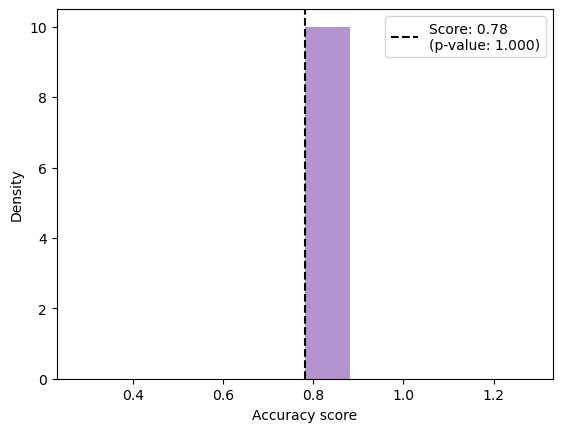

Mean Accuracy: 0.766 (0.006)


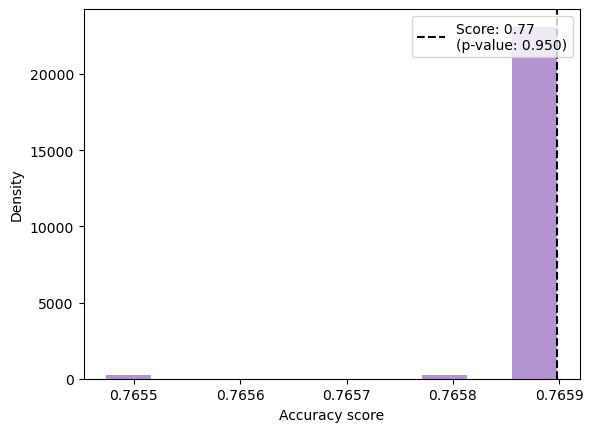

Mean Accuracy: 0.765 (0.005)


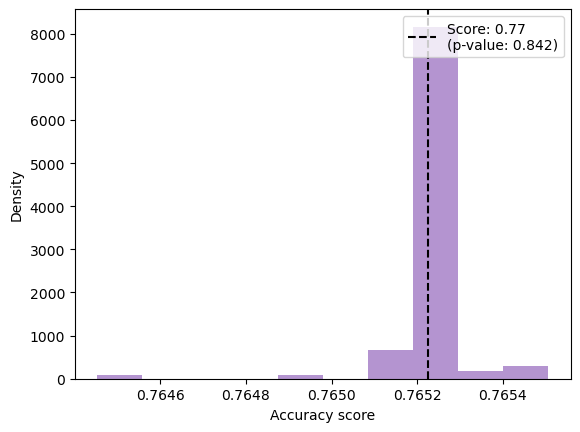

Mean Accuracy: 0.765 (0.005)


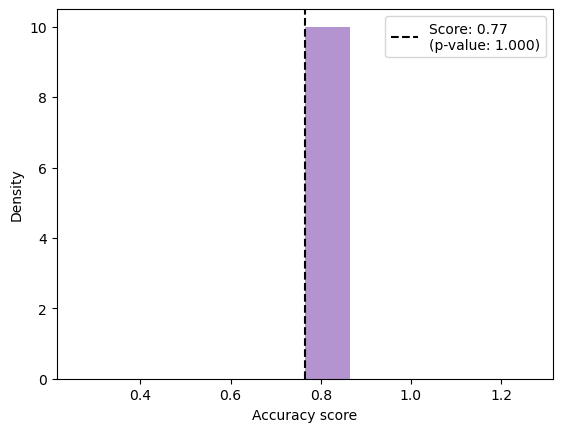

Mean Accuracy: 0.792 (0.033)


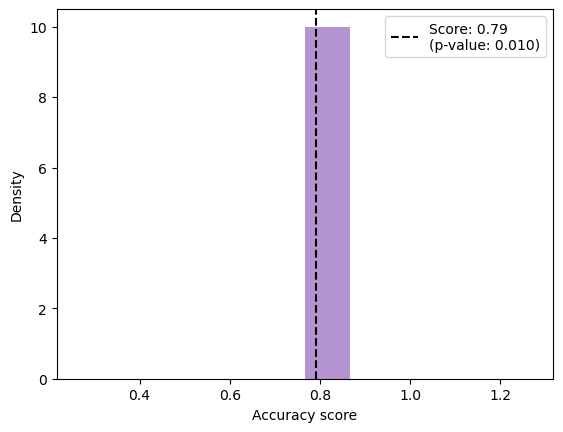

Mean Accuracy: 0.766 (0.006)


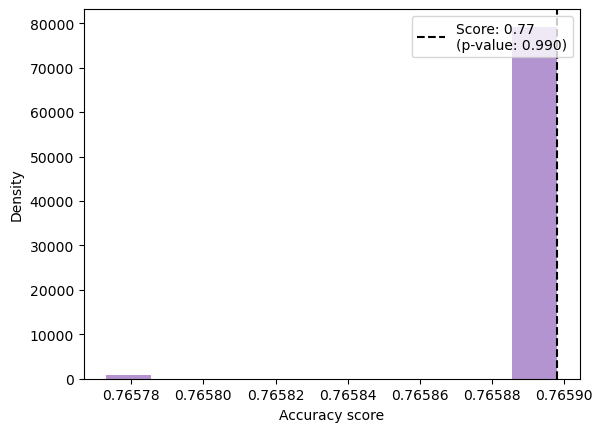

Mean Accuracy: 0.765 (0.005)


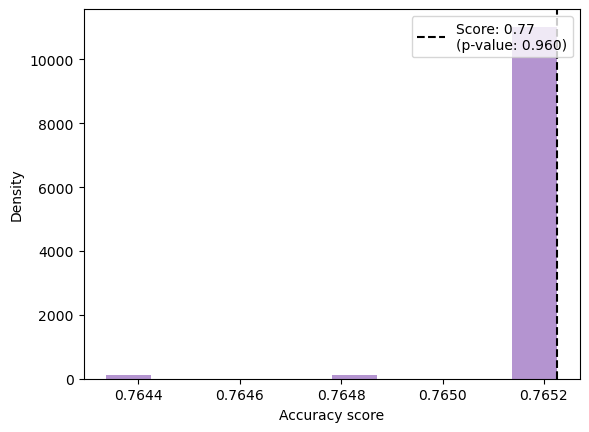

In [32]:
# o=single_lda(df)
p=single_lda(df)

In [30]:
o

,mean_accuracy,std,mean_score,perm_accuaracy,p-value,perm_std,perm_accuracy
speed,0.755998,0.006688,0.650958,NaN,1.0,3.330669e-16,0.755998
Angular_speed,0.762208,0.0065,0.662519,NaN,1.0,9.576475e-06,0.765897
curvature,0.765226,0.005116,0.663456,NaN,0.455446,5.387366e-04,0.764942
head_frequency,0.765226,0.005116,0.663456,NaN,1.0,1.110223e-16,0.765226
rev_run,0.749987,0.017232,0.663687,NaN,1.0,2.251971e-04,0.761946
roam_dwell,0.765898,0.0057,0.664371,NaN,1.0,1.945268e-16,0.765898
head_curvature,0.765226,0.005116,0.663456,NaN,1.0,1.110223e-16,0.765226


In [33]:
p

,mean_accuracy,std,mean_score,perm_accuaracy,p-value,perm_std,perm_accuracy
speed,0.781927,0.001416,0.686234,NaN,1.0,3.330669e-16,0.781927
Angular_speed,0.765898,0.0057,0.664371,NaN,0.950495,4.352097e-05,0.765892
curvature,0.765226,0.005116,0.663456,NaN,0.841584,9.427014e-05,0.765223
head_frequency,0.765226,0.005116,0.663456,NaN,1.0,1.110223e-16,0.765226
rev_run,0.792029,0.03303,0.761506,NaN,0.009901,2.220446e-16,0.766990
roam_dwell,0.765898,0.0057,0.664371,NaN,0.990099,1.243734e-05,0.765897
head_curvature,0.765226,0.005116,0.663456,NaN,0.960396,9.765763e-05,0.765212
